In [38]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [39]:
print(f'Pandas version: {pd.__version__}')
print(f'Matplotlib version: {matplotlib.__version__}')

Pandas version: 3.0.2
Matplotlib version: 3.10.9


In [40]:
df = pd.read_csv('raw_coffee_sales.csv')

df.head()

,OrderID,Date,Region,Store,Category,Product,UnitsSold,Revenue,Cost,DiscountPercent
0,1001,05/01/2026,East,providence cafe,Coffee,Latte,45,$247.50,$135.00,0.0
1,1002,2026-05-01,East,Providence Cafe,Food,Muffin,30,105,42,10.0
2,1003,2026/05/01,west,Seattle central,Coffee,Cold Brew,52,$286.00,$140.00,5.0
3,1004,05-02-2026,South,Austin beans,Tea,Chai Latte,28,126,56,NaN
4,1005,2026-05-02,West,Seattle Central,Food,Bagel,40,$140.00,$52.00,15.0


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          52 non-null     int64  
 1   Date             52 non-null     str    
 2   Region           51 non-null     str    
 3   Store            52 non-null     str    
 4   Category         52 non-null     str    
 5   Product          52 non-null     str    
 6   UnitsSold        52 non-null     str    
 7   Revenue          52 non-null     str    
 8   Cost             52 non-null     str    
 9   DiscountPercent  50 non-null     float64
dtypes: float64(1), int64(1), str(8)
memory usage: 7.0 KB


In [42]:
df.describe()

,OrderID,DiscountPercent
count,52.000000,50.000000
mean,1024.865385,3.700000
std,14.691639,5.031533
min,1001.000000,0.000000
25%,1012.750000,0.000000
50%,1024.500000,0.000000
75%,1037.250000,5.000000
max,1050.000000,20.000000


### Clean dataset

cleanup `raw_coffee_sales.csv` and save to `clean_coffee_sales.csv`.

In [43]:
raw_df = pd.read_csv("raw_coffee_sales.csv")
clean_df = raw_df.copy()

clean_df = clean_df.rename(columns={
    "OrderID": "order_id",
    "Date": "date",
    "Region": "region",
    "Store": "store",
    "Category": "category",
    "Product": "product",
    "UnitsSold": "units_sold",
    "Revenue": "revenue",
    "Cost": "cost",
    "DiscountPercent": "discount_percent",
})

# Standardize text fields
text_cols = ["region", "store", "category", "product"]
for col in text_cols:
    clean_df[col] = clean_df[col].astype("string").str.strip().str.title()

# Convert mixed date formats and money strings to analysis-ready types
clean_df["date"] = pd.to_datetime(clean_df["date"], errors="coerce", format="mixed")
for col in ["revenue", "cost"]:
    clean_df[col] = pd.to_numeric(
        clean_df[col].astype("string").str.replace(r"[$,]", "", regex=True).str.strip(),
        errors="coerce",
    )

clean_df["units_sold"] = pd.to_numeric(clean_df["units_sold"], errors="coerce")

# Fill missing region from the store-region mapping and missing discount with 0
missing_discount_count = clean_df["discount_percent"].isna().sum()
missing_region_before = clean_df["region"].isna().sum()
store_region_map = (
    clean_df.dropna(subset=["region"])
    .drop_duplicates(subset=["store"])
    .set_index("store")["region"]
)
clean_df["region"] = clean_df["region"].fillna(clean_df["store"].map(store_region_map))
regions_inferred = missing_region_before - clean_df["region"].isna().sum()
clean_df["discount_percent"] = pd.to_numeric(clean_df["discount_percent"], errors="coerce").fillna(0)

# Remove duplicate orders and rows with invalid core values
duplicate_order_count = clean_df.duplicated(subset=["order_id"]).sum()
clean_df = clean_df.drop_duplicates(subset=["order_id"], keep="first")
rows_before_core_drop = len(clean_df)
clean_df = clean_df.dropna(subset=[
    "date",
    "region",
    "store",
    "category",
    "product",
    "units_sold",
    "revenue",
    "cost",
])
invalid_core_rows_removed = rows_before_core_drop - len(clean_df)

# Add columns useful for sales analysis
clean_df["units_sold"] = clean_df["units_sold"].astype("int64")
clean_df["gross_profit"] = clean_df["revenue"] - clean_df["cost"]
clean_df["profit_margin"] = (clean_df["gross_profit"] / clean_df["revenue"]).round(4)
clean_df["avg_price_per_unit"] = (clean_df["revenue"] / clean_df["units_sold"]).round(2)
clean_df["month"] = clean_df["date"].dt.to_period("M").astype(str)
clean_df["day_name"] = clean_df["date"].dt.day_name()
clean_df["date"] = clean_df["date"].dt.date

clean_df = clean_df.sort_values(["date", "order_id"]).reset_index(drop=True)
clean_df.to_csv("clean_coffee_sales.csv", index=False)

cleaning_summary = pd.Series({
    "raw_rows": len(raw_df),
    "duplicates_removed": int(duplicate_order_count),
    "invalid_core_rows_removed": int(invalid_core_rows_removed),
    "missing_regions_inferred": int(regions_inferred),
    "missing_discounts_filled": int(missing_discount_count),
    "clean_rows": len(clean_df),
    "output_file": "clean_coffee_sales.csv",
})

cleaning_summary

raw_rows                                         52
duplicates_removed                                2
invalid_core_rows_removed                         4
missing_regions_inferred                          1
missing_discounts_filled                          2
clean_rows                                       46
output_file                  clean_coffee_sales.csv
dtype: object

In [44]:
display(clean_df.head())
clean_df.info()
display(clean_df.isna().sum().to_frame("missing_values"))

,order_id,date,region,store,category,product,units_sold,revenue,cost,discount_percent,gross_profit,profit_margin,avg_price_per_unit,month,day_name
0,1001,2026-05-01,East,Providence Cafe,Coffee,Latte,45,247.5,135.0,0.0,112.5,0.4545,5.5,2026-05,Friday
1,1002,2026-05-01,East,Providence Cafe,Food,Muffin,30,105.0,42.0,10.0,63.0,0.6,3.5,2026-05,Friday
2,1003,2026-05-01,West,Seattle Central,Coffee,Cold Brew,52,286.0,140.0,5.0,146.0,0.5105,5.5,2026-05,Friday
3,1004,2026-05-02,South,Austin Beans,Tea,Chai Latte,28,126.0,56.0,0.0,70.0,0.5556,4.5,2026-05,Saturday
4,1005,2026-05-02,West,Seattle Central,Food,Bagel,40,140.0,52.0,15.0,88.0,0.6286,3.5,2026-05,Saturday


<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            46 non-null     int64  
 1   date                46 non-null     object 
 2   region              46 non-null     string 
 3   store               46 non-null     string 
 4   category            46 non-null     string 
 5   product             46 non-null     string 
 6   units_sold          46 non-null     int64  
 7   revenue             46 non-null     Float64
 8   cost                46 non-null     Float64
 9   discount_percent    46 non-null     float64
 10  gross_profit        46 non-null     Float64
 11  profit_margin       46 non-null     Float64
 12  avg_price_per_unit  46 non-null     Float64
 13  month               46 non-null     str    
 14  day_name            46 non-null     str    
dtypes: Float64(5), float64(1), int64(2), object(1), str(2), string(4)
memo

,missing_values
order_id,0
date,0
region,0
store,0
category,0
product,0
units_sold,0
revenue,0
cost,0
discount_percent,0


### Sales charts and recommendations

Phan nay dung clean dataset de xem revenue, gross profit, top product, store performance va dua ra recommendation.

In [45]:
sales_df = pd.read_csv("clean_coffee_sales.csv", parse_dates=["date"])

daily_summary = (
    sales_df.groupby("date")
    .agg(revenue=("revenue", "sum"), gross_profit=("gross_profit", "sum"), units_sold=("units_sold", "sum"))
    .reset_index()
)

category_summary = (
    sales_df.groupby("category")
    .agg(revenue=("revenue", "sum"), gross_profit=("gross_profit", "sum"), units_sold=("units_sold", "sum"), orders=("order_id", "count"))
    .assign(profit_margin=lambda x: x["gross_profit"] / x["revenue"])
    .sort_values("revenue", ascending=False)
)

product_summary = (
    sales_df.groupby("product")
    .agg(revenue=("revenue", "sum"), gross_profit=("gross_profit", "sum"), units_sold=("units_sold", "sum"), orders=("order_id", "count"))
    .assign(profit_margin=lambda x: x["gross_profit"] / x["revenue"])
    .sort_values("revenue", ascending=False)
)

store_summary = (
    sales_df.groupby(["region", "store"])
    .agg(revenue=("revenue", "sum"), gross_profit=("gross_profit", "sum"), units_sold=("units_sold", "sum"), orders=("order_id", "count"))
    .assign(profit_margin=lambda x: x["gross_profit"] / x["revenue"])
    .sort_values("revenue", ascending=False)
)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = (
    sales_df.groupby("day_name")
    .agg(revenue=("revenue", "sum"), gross_profit=("gross_profit", "sum"), units_sold=("units_sold", "sum"), orders=("order_id", "count"))
    .reindex(weekday_order)
    .dropna()
)

display(category_summary.style.format({"revenue": "${:,.0f}", "gross_profit": "${:,.0f}", "profit_margin": "{:.1%}"}))
display(product_summary.head(10).style.format({"revenue": "${:,.0f}", "gross_profit": "${:,.0f}", "profit_margin": "{:.1%}"}))
display(store_summary.style.format({"revenue": "${:,.0f}", "gross_profit": "${:,.0f}", "profit_margin": "{:.1%}"}))

,revenue,gross_profit,units_sold,orders,profit_margin
category,,,,,
Coffee,"$4,755","$2,471",1096,21,52.0%
Food,"$1,739","$1,072",517,15,61.6%
Tea,"$1,166",$682,279,10,58.5%


,revenue,gross_profit,units_sold,orders,profit_margin
product,,,,,
Latte,"$1,255",$575,228,5,45.8%
Americano,$915,$572,280,4,62.5%
Espresso,$660,$391,235,3,59.2%
Mocha,$588,$276,106,3,46.9%
Cold Brew,$586,$296,107,2,50.5%
Chai Latte,$524,$293,121,4,55.9%
Bagel,$520,$308,130,4,59.2%
Cookie,$435,$300,175,3,69.0%
Cappuccino,$419,$195,80,2,46.5%


,,revenue,gross_profit,units_sold,orders,profit_margin
region,store,,,,,
East,Providence Cafe,"$3,057","$1,571",640,18,51.4%
South,Austin Beans,"$2,434","$1,491",771,14,61.3%
West,Seattle Central,"$2,170","$1,164",481,14,53.6%


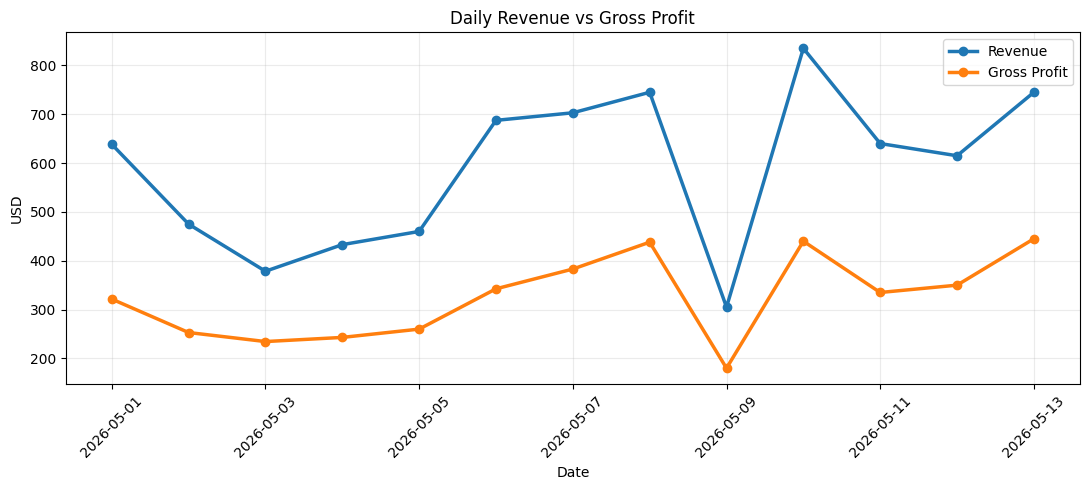

In [46]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(daily_summary["date"], daily_summary["revenue"], marker="o", linewidth=2.5, label="Revenue")
ax.plot(daily_summary["date"], daily_summary["gross_profit"], marker="o", linewidth=2.5, label="Gross Profit")

ax.set_title("Daily Revenue vs Gross Profit")
ax.set_xlabel("Date")
ax.set_ylabel("USD")
ax.legend()
ax.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

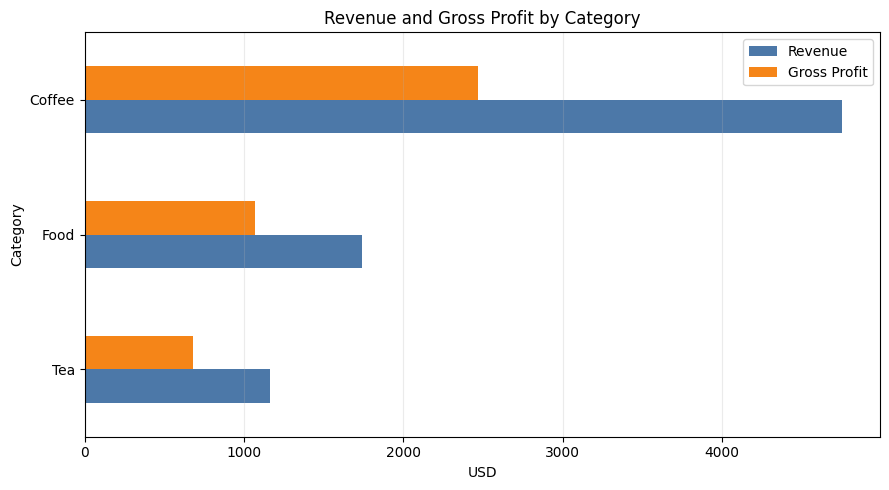

In [47]:
category_plot = category_summary[["revenue", "gross_profit"]].sort_values("revenue")

fig, ax = plt.subplots(figsize=(9, 5))
category_plot.plot(kind="barh", ax=ax, color=["#4C78A8", "#F58518"])

ax.set_title("Revenue and Gross Profit by Category")
ax.set_xlabel("USD")
ax.set_ylabel("Category")
ax.grid(axis="x", alpha=0.25)
ax.legend(["Revenue", "Gross Profit"])
plt.tight_layout()
plt.show()

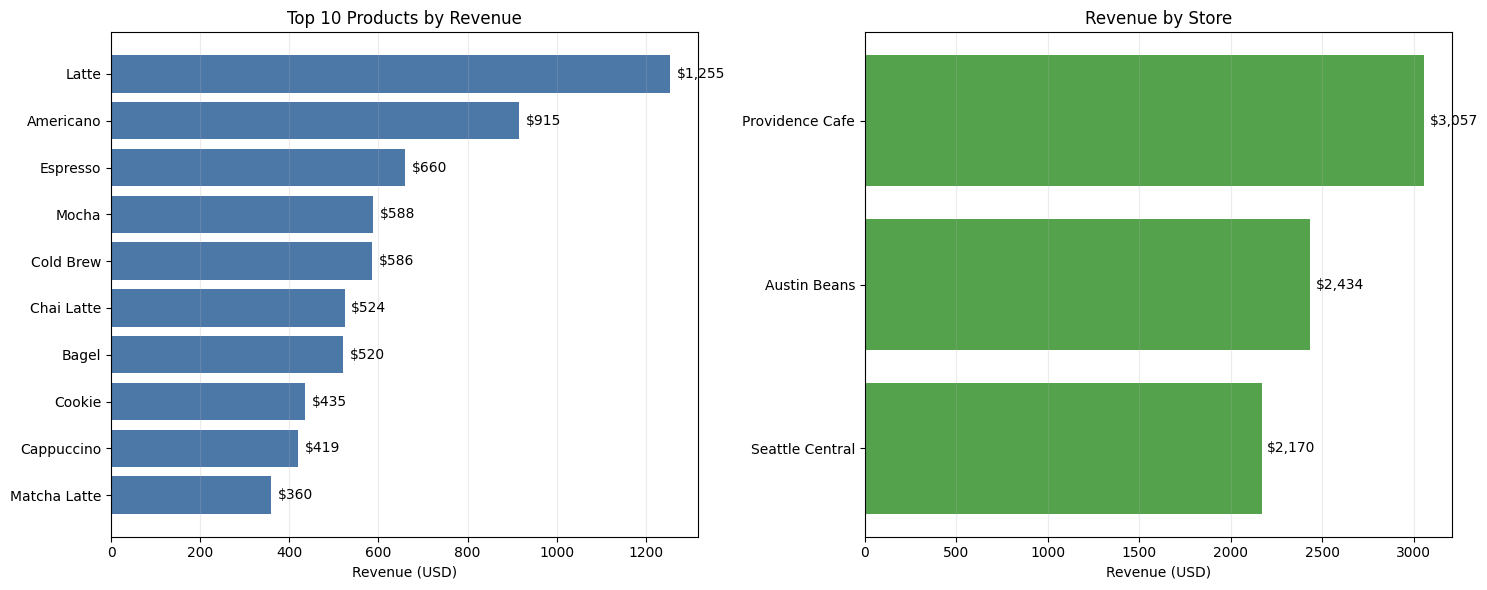

In [48]:
top_products = product_summary.head(10).sort_values("revenue")
store_plot = store_summary.reset_index().sort_values("revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top_products.index, top_products["revenue"], color="#4C78A8")
axes[0].set_title("Top 10 Products by Revenue")
axes[0].set_xlabel("Revenue (USD)")
axes[0].grid(axis="x", alpha=0.25)

for i, value in enumerate(top_products["revenue"]):
    axes[0].text(value + 15, i, f"${value:,.0f}", va="center")

axes[1].barh(store_plot["store"], store_plot["revenue"], color="#54A24B")
axes[1].set_title("Revenue by Store")
axes[1].set_xlabel("Revenue (USD)")
axes[1].grid(axis="x", alpha=0.25)

for i, value in enumerate(store_plot["revenue"]):
    axes[1].text(value + 30, i, f"${value:,.0f}", va="center")

plt.tight_layout()
plt.show()

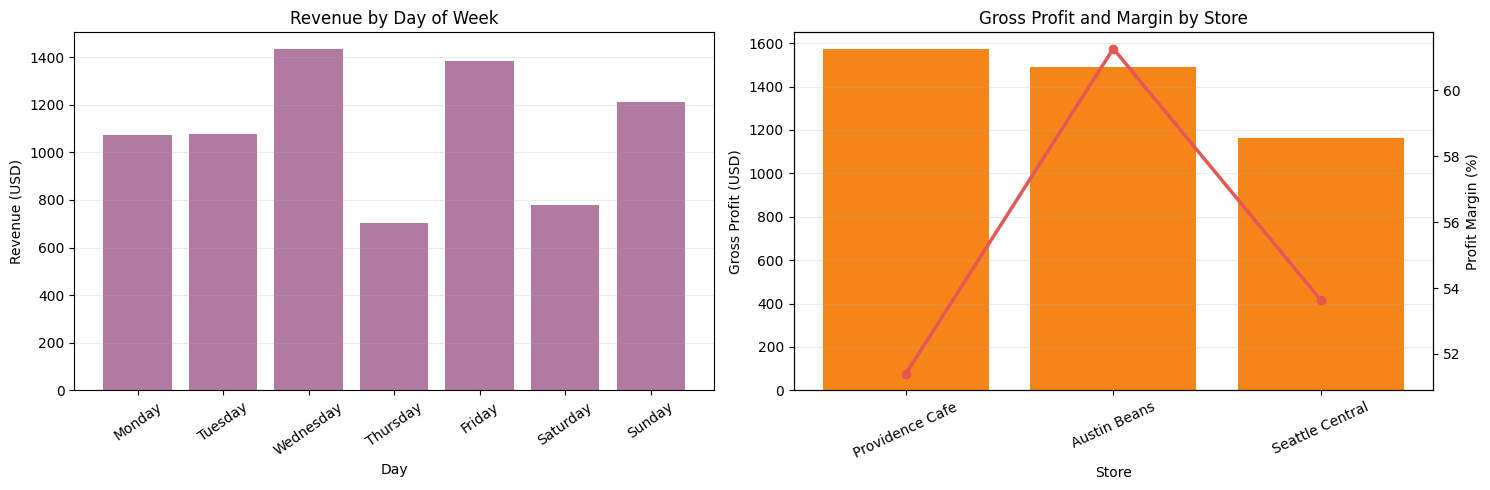

In [49]:
store_margin_plot = store_summary.reset_index().sort_values("revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(weekday_summary.index, weekday_summary["revenue"], color="#B279A2")
axes[0].set_title("Revenue by Day of Week")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Revenue (USD)")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(store_margin_plot["store"], store_margin_plot["gross_profit"], color="#F58518", label="Gross Profit")
axes[1].set_title("Gross Profit and Margin by Store")
axes[1].set_xlabel("Store")
axes[1].set_ylabel("Gross Profit (USD)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25)

margin_axis = axes[1].twinx()
margin_axis.plot(store_margin_plot["store"], store_margin_plot["profit_margin"] * 100, color="#E45756", marker="o", linewidth=2.5, label="Margin")
margin_axis.set_ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

In [50]:
top_category = category_summary.index[0]
top_product_revenue = product_summary.index[0]
top_product_profit = product_summary.drop(index=top_product_revenue).sort_values("gross_profit", ascending=False).index[0]
highest_margin_product = product_summary[product_summary["orders"] >= 3].sort_values("profit_margin", ascending=False).index[0]
top_store_revenue = store_summary.index[0][1]
top_store_margin = store_summary.sort_values("profit_margin", ascending=False).index[0][1]
best_weekday = weekday_summary.sort_values("revenue", ascending=False).index[0]

recommendations = pd.DataFrame([
    {
        "priority": 1,
        "recommendation": f"Protect and grow {top_category} sales.",
        "reason": f"{top_category} leads revenue at ${category_summary.loc[top_category, 'revenue']:,.0f} and gross profit at ${category_summary.loc[top_category, 'gross_profit']:,.0f}.",
        "action": "Keep stock strong for core coffee products and test bundles with Food/Tea to lift basket size.",
    },
    {
        "priority": 2,
        "recommendation": f"Push {top_product_profit} and {highest_margin_product} more aggressively.",
        "reason": f"{top_product_profit} is the top gross-profit product; {highest_margin_product} has the best margin among products with 3+ orders.",
        "action": "Feature them in menu placement, staff upsell prompts, and light promotions during high-traffic days.",
    },
    {
        "priority": 3,
        "recommendation": f"Review cost or pricing for {top_product_revenue}.",
        "reason": f"{top_product_revenue} has the highest revenue, but margin is only {product_summary.loc[top_product_revenue, 'profit_margin']:.1%}.",
        "action": "Check ingredient cost, portioning, and price elasticity before discounting this product.",
    },
    {
        "priority": 4,
        "recommendation": f"Use {top_store_margin} as the margin benchmark for other stores.",
        "reason": f"{top_store_revenue} leads revenue, while {top_store_margin} has the highest store margin at {store_summary.sort_values('profit_margin', ascending=False).iloc[0]['profit_margin']:.1%}.",
        "action": "Compare product mix and operating practices between stores, then copy the profitable mix where possible.",
    },
    {
        "priority": 5,
        "recommendation": f"Plan staffing and inventory around {best_weekday} demand.",
        "reason": f"{best_weekday} has the highest revenue by weekday at ${weekday_summary.loc[best_weekday, 'revenue']:,.0f}.",
        "action": "Schedule enough staff and prep inventory before peak days to avoid lost sales.",
    },
])

from IPython.display import HTML
import html

recommendation_cards = []
for _, row in recommendations.iterrows():
    priority = int(row['priority'])
    recommendation = html.escape(row['recommendation'])
    reason = html.escape(row['reason'])
    action = html.escape(row['action'])
    recommendation_cards.append(
        "<div style='max-width: 860px; border: 1px solid #ddd; border-radius: 8px; padding: 12px; margin: 10px 0; line-height: 1.45; white-space: normal;'>"
        f"<div style='font-weight: 700; font-size: 16px; margin-bottom: 6px;'>{priority}. {recommendation}</div>"
        f"<div style='margin-bottom: 4px;'><strong>Reason:</strong> {reason}</div>"
        f"<div><strong>Action:</strong> {action}</div>"
        "</div>"
    )

HTML("<div style='max-width: 900px;'>" + "".join(recommendation_cards) + "</div>")